In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

In [5]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [6]:
train = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

val = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

Found 5054 files belonging to 2 classes.
Using 4044 files for training.
Found 5054 files belonging to 2 classes.
Using 1010 files for validation.


In [7]:
class_names = train.class_names
print(class_names)

['Garbage classification', 'garbage classification']


In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train = train.map(lambda x, y: (normalization_layer(x), y))
val = val.map(lambda x, y: (normalization_layer(x), y))

In [9]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 996ms/step - accuracy: 0.5032 - loss: 0.7041 - val_accuracy: 0.5297 - val_loss: 0.6919
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.5052 - loss: 0.6942 - val_accuracy: 0.4703 - val_loss: 0.6935
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 139s 979ms/step - accuracy: 0.5062 - loss: 0.6934 - val_accuracy: 0.4703 - val_loss: 0.6940
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.5079 - loss: 0.6932 - val_accuracy: 0.4703 - val_loss: 0.6940
Epoch 5/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 126s 992ms/step - accuracy: 0.5077 - loss: 0.6931 - val_accuracy: 0.4703 - val_loss: 0.6939
Epoch 6/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5074 - loss: 0.6929 - val_accuracy: 0.4703 - val_loss: 0.6941
Epoch 7/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 139s 981ms/step - accuracy: 0.4990 - loss: 0.6931 - val_accuracy: 0.4703 - val_loss: 0.6938
Epoch 8/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.5000 - loss: 0.693

In [12]:
loss, accuracy = model.evaluate(val)

print("Validation Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.4703 - loss: 0.6942
Validation Accuracy: 0.47029703855514526


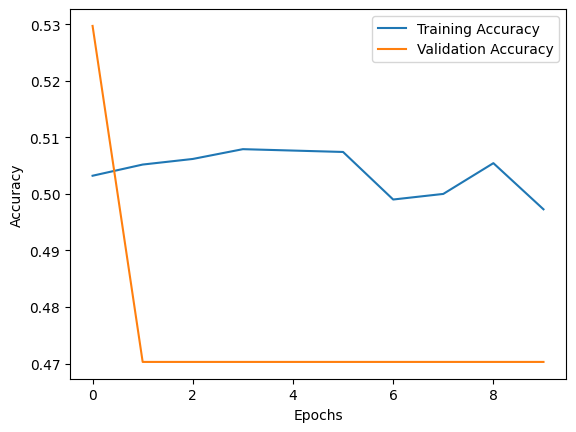

In [13]:
plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

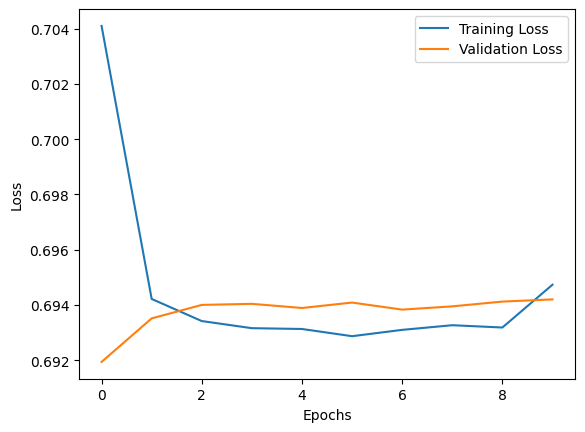

In [14]:
plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

folder = "Garbage classification/cardboard"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

img = image.load_img(img_path, target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Garbage classification/cardboard'